# Tarea M23-CD – Lucy Bravo
## Clasificación multiclase con Árboles de Decisión — recomendación de fármaco

**Problema.** Somos investigadores médicos con datos de 200 pacientes que padecen la misma
enfermedad. Cada paciente respondió a uno de cinco fármacos (**drugA, drugB, drugC, drugX, drugY**).
Queremos construir un modelo que, a partir de las características del paciente, prediga a qué
fármaco respondería.

| Elemento | Detalle |
|---|---|
| Variables predictoras | `Age` (edad), `Sex` (sexo), `BP` (presión arterial), `Cholesterol` (colesterol), `Na_to_K` (razón sodio/potasio en sangre) |
| **Variable a pronosticar** | `Drug` — el fármaco al que respondió el paciente (5 categorías) |
| Tipo de problema | Clasificación **multiclase** (5 clases) |
| Técnica | Árbol de decisión (`DecisionTreeClassifier`), criterios *Gini* y *Entropía* |

**Por qué un árbol de decisión.** En un contexto clínico no basta con acertar: hay que poder
*explicar* la recomendación. El árbol produce reglas legibles del tipo "si el Na_to_K es alto,
entonces drugY", que un médico puede auditar. Además maneja sin problema una mezcla de variables
numéricas y categóricas y no exige escalar los datos.


---
## 1. Librerías

Cargamos únicamente lo necesario. `preprocessing` de scikit-learn es el módulo que trae
`LabelEncoder`, la herramienta que la actividad pide usar para volver numéricas las variables
cualitativas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 110
# semilla fija: garantiza resultados reproducibles
RANDOM_STATE = 3

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 2. Carga y exploración de la base de datos

Antes de modelar hay que conocer los datos: cuántos registros hay, de qué tipo es cada columna,
si faltan valores y cómo se reparten las clases. Este diagnóstico decide después cómo
interpretamos las métricas.

In [2]:
df = pd.read_csv('drugs.csv')

print('Dimensiones (filas, columnas):', df.shape)
df.head(10)

Dimensiones (filas, columnas): (200, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
5,22,F,NORMAL,HIGH,8.607,drugX
6,49,F,NORMAL,HIGH,16.275,drugY
7,41,M,LOW,HIGH,11.037,drugC
8,60,M,NORMAL,HIGH,15.171,drugY
9,43,M,LOW,NORMAL,19.368,drugY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


**Lectura:** 200 registros y 6 columnas, **sin valores faltantes** (los 200 no nulos en cada
columna). `Age` es entero, `Na_to_K` es decimal y `Sex`, `BP`, `Cholesterol` y `Drug` son texto
(`object`). Esas cuatro columnas de texto son las que hay que convertir a número.

In [4]:
# Estadísticos de las variables numéricas
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [5]:
# Categorías presentes en cada variable cualitativa
for col in ['Sex', 'BP', 'Cholesterol', 'Drug']:
    print(f'{col:12s} -> {sorted(df[col].unique())}')

Sex          -> ['F', 'M']
BP           -> ['HIGH', 'LOW', 'NORMAL']
Cholesterol  -> ['HIGH', 'NORMAL']
Drug         -> ['drugA', 'drugB', 'drugC', 'drugX', 'drugY']


Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64 

Drug
drugY    45.5 %
drugX    27.0 %
drugA    11.5 %
drugC     8.0 %
drugB     8.0 %
Name: count, dtype: str


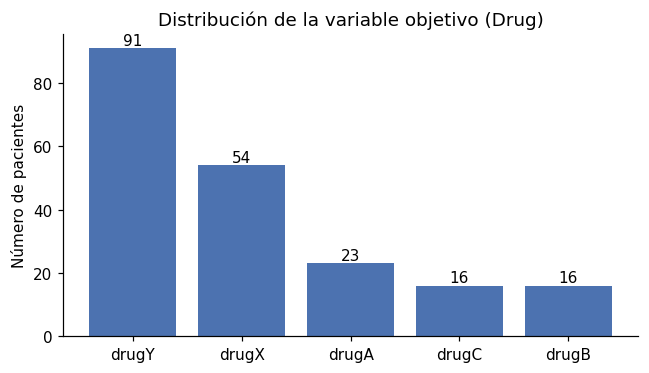

In [6]:
# Distribución de la variable objetivo
conteo = df['Drug'].value_counts()
print(conteo, '\n')
print((conteo / len(df) * 100).round(1).astype(str) + ' %')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(conteo.index, conteo.values, color='#4C72B0')
ax.set_title('Distribución de la variable objetivo (Drug)')
ax.set_ylabel('Número de pacientes')
for i, v in enumerate(conteo.values):
    ax.text(i, v + 1, str(v), ha='center')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**Interpretación.** Las clases están **desbalanceadas**: `drugY` concentra 91 pacientes (45.5 %)
y `drugX` 54 (27 %), mientras que `drugB` y `drugC` apenas tienen 16 casos cada uno (8 %).

Esto tiene una consecuencia práctica importante: la **exactitud (accuracy) sola puede engañar**.
Un modelo que dijera "drugY" a todo el mundo acertaría ~45 % sin haber aprendido nada. Por eso más
adelante veremos *precision*, *recall* y *f1-score* **por clase**, que sí revelan si el modelo
reconoce a las clases minoritarias.

---
## 3. Codificación de variables cualitativas con `LabelEncoder`

Los árboles de scikit-learn trabajan con números, no con texto. `preprocessing.LabelEncoder()`
asigna a cada categoría un entero (0, 1, 2, …) siguiendo el **orden alfabético** de las etiquetas.

Un detalle honesto que conviene tener presente: `LabelEncoder` introduce un orden numérico
artificial (HIGH=0 < LOW=1 < NORMAL=2, que no es un orden clínico real). En modelos lineales eso
sería un problema; en un **árbol** no lo es tanto, porque el árbol parte el espacio con cortes del
tipo "≤ 0.5" y puede aislar cada categoría con cortes sucesivos. Aun así lo dejamos anotado, y por
eso más abajo guardamos los diccionarios de equivalencia para poder traducir las reglas del árbol
de vuelta a lenguaje humano.

In [7]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].copy()
y = df['Drug'].copy()

mapas = {}   # guardamos las equivalencias categoría -> número

for col in ['Sex', 'BP', 'Cholesterol']:
    le = preprocessing.LabelEncoder()
    le.fit(X[col])
    X[col] = le.transform(X[col])
    codigos = le.transform(le.classes_).tolist()
    mapas[col] = dict(zip(le.classes_, codigos))
    print(f'{col:12s} -> {mapas[col]}')

print()
X.head(10)

Sex          -> {'F': 0, 'M': 1}
BP           -> {'HIGH': 0, 'LOW': 1, 'NORMAL': 2}
Cholesterol  -> {'HIGH': 0, 'NORMAL': 1}



,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043
5,22,0,2,0,8.607
6,49,0,2,0,16.275
7,41,1,1,0,11.037
8,60,1,2,0,15.171
9,43,1,1,1,19.368


**Equivalencias resultantes** (memorícelas, se usan para leer el árbol):

| Variable | Codificación |
|---|---|
| `Sex` | F = 0, M = 1 |
| `BP` | HIGH = 0, LOW = 1, NORMAL = 2 |
| `Cholesterol` | HIGH = 0, NORMAL = 1 |

La variable objetivo `Drug` **no** la codificamos: scikit-learn acepta etiquetas de texto en `y`, y
dejarla como texto hace que los reportes salgan con los nombres reales de los fármacos, mucho más
fáciles de leer.

---
## 4. Partición en entrenamiento y prueba

Separamos 70 % para entrenar y 30 % para probar. La clave es `stratify=y`: obliga a que la
proporción de cada fármaco sea la misma en ambos conjuntos. Sin eso, con clases de solo 16 casos,
podría ocurrir que `drugB` casi no apareciera en la prueba y la evaluación no significaría nada.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

print(f'Entrenamiento: {X_train.shape[0]} pacientes')
print(f'Prueba:        {X_test.shape[0]} pacientes\n')

comparacion = pd.DataFrame({
    'Entrenamiento': y_train.value_counts(),
    'Prueba': y_test.value_counts()
}).fillna(0).astype(int)
comparacion['% Entren.'] = (comparacion['Entrenamiento']
                            / len(y_train) * 100).round(1)
comparacion['% Prueba'] = (comparacion['Prueba']
                           / len(y_test) * 100).round(1)
comparacion

Entrenamiento: 140 pacientes
Prueba:        60 pacientes



,Entrenamiento,Prueba,% Entren.,% Prueba
Drug,,,,
drugA,16,7,11.4,11.7
drugB,11,5,7.9,8.3
drugC,11,5,7.9,8.3
drugX,38,16,27.1,26.7
drugY,64,27,45.7,45.0


Las proporciones coinciden entre ambos conjuntos: la partición es representativa.

---
## 5. Entrenamiento: Gini vs. Entropía y distintos niveles de profundidad

### ¿Qué mide cada criterio?

Ambos responden a la misma pregunta —*¿qué tan mezcladas están las clases en este nodo?*— y el
árbol elige en cada paso la partición que **más reduce** esa mezcla (impureza).

- **Gini** = $1 - \sum_i p_i^2$. Es la probabilidad de equivocarse si etiquetáramos un caso al azar
  según la distribución del nodo. Vale 0 cuando el nodo es puro. Es rápido de calcular.
- **Entropía** = $-\sum_i p_i \log_2 p_i$. Viene de la teoría de la información: mide los *bits* de
  incertidumbre del nodo. También vale 0 en un nodo puro, pero penaliza un poco más las mezclas
  fuertes, así que a veces produce cortes ligeramente distintos.

### ¿Qué controla `max_depth`?

Es el número máximo de preguntas encadenadas. Poca profundidad → modelo simple que puede quedarse
corto (*subajuste*). Demasiada → el árbol memoriza el ruido del entrenamiento y falla con datos
nuevos (*sobreajuste*). Buscamos el punto donde el desempeño en prueba deja de mejorar.

In [9]:
profundidades = [2, 3, 4, 5, 6, None]   # None = sin límite
resultados = []
modelos = {}

for criterio in ['gini', 'entropy']:
    for prof in profundidades:
        modelo = DecisionTreeClassifier(criterion=criterio,
                                        max_depth=prof,
                                        random_state=RANDOM_STATE)
        modelo.fit(X_train, y_train)

        acc_tr = accuracy_score(y_train, modelo.predict(X_train))
        acc_te = accuracy_score(y_test,  modelo.predict(X_test))

        modelos[(criterio, prof)] = modelo
        resultados.append({
            'Criterio': criterio,
            'max_depth': 'Sin límite' if prof is None else prof,
            'Exactitud entrenamiento': round(acc_tr, 4),
            'Exactitud prueba': round(acc_te, 4),
            'Brecha (sobreajuste)': round(acc_tr - acc_te, 4),
            'Profundidad real': modelo.get_depth(),
            'Hojas': modelo.get_n_leaves()
        })

tabla = pd.DataFrame(resultados)
tabla

,Criterio,max_depth,Exactitud entrenamiento,Exactitud prueba,Brecha (sobreajuste),Profundidad real,Hojas
0,gini,2,0.8429,0.8333,0.0095,2,3
1,gini,3,0.9214,0.9167,0.0048,3,5
2,gini,4,1.0000,1.0000,0.0000,4,6
3,gini,5,1.0000,1.0000,0.0000,4,6
4,gini,6,1.0000,1.0000,0.0000,4,6
5,gini,Sin límite,1.0000,1.0000,0.0000,4,6
6,entropy,2,0.8429,0.8333,0.0095,2,3
7,entropy,3,0.9214,0.9167,0.0048,3,5
8,entropy,4,1.0000,1.0000,0.0000,4,6
9,entropy,5,1.0000,1.0000,0.0000,4,6


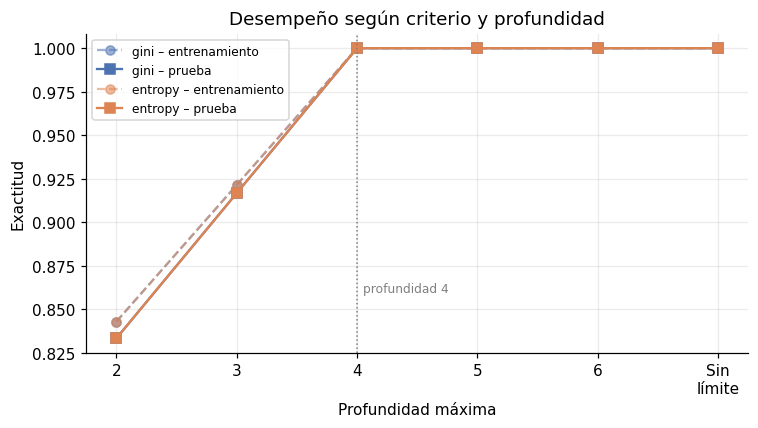

In [10]:
# Curva de desempeño frente a la profundidad
fig, ax = plt.subplots(figsize=(7, 4))
for criterio, color in [('gini', '#4C72B0'), ('entropy', '#DD8452')]:
    sub = tabla[tabla['Criterio'] == criterio]
    xs = [7 if p == 'Sin límite' else p for p in sub['max_depth']]
    ax.plot(xs, sub['Exactitud entrenamiento'], '--o',
            color=color, alpha=.55,
            label=f'{criterio} – entrenamiento')
    ax.plot(xs, sub['Exactitud prueba'], '-s', color=color,
            label=f'{criterio} – prueba')
ax.set_xticks([2, 3, 4, 5, 6, 7])
ax.set_xticklabels(['2', '3', '4', '5', '6', 'Sin\nlímite'])
ax.set_xlabel('Profundidad máxima'); ax.set_ylabel('Exactitud')
ax.set_title('Desempeño según criterio y profundidad')
ax.axvline(4, color='grey', ls=':', lw=1)
ax.text(4.05, 0.86, 'profundidad 4', fontsize=8, color='grey')
ax.legend(fontsize=8); ax.grid(alpha=.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**Lectura de la tabla y la curva.**

- Con **profundidad 2** el modelo llega a ~83 % en prueba: es **subajuste**. Con solo dos preguntas
  no alcanza a distinguir los cinco fármacos, y de hecho el árbol produce apenas 3 hojas para 5
  clases, así que hay clases que *nunca* puede predecir.
- Con **profundidad 3** sube a ~92 %, pero todavía le faltan hojas para cubrir todas las clases.
- A partir de **profundidad 4** el modelo clasifica correctamente el 100 % tanto en entrenamiento
  como en prueba, con solo 6 hojas.
- Subir a 5, 6 o quitar el límite **no cambia nada**: el árbol deja de crecer solo, porque ya
  alcanzó nodos puros. La "profundidad real" se queda en 4 en todos esos casos.
- **Gini y entropía dan resultados idénticos** en cada profundidad. No es casualidad: los dos
  criterios miden impureza de forma muy parecida y, cuando las fronteras entre clases son tan
  nítidas como aquí, ambos eligen los mismos cortes.

La brecha entre entrenamiento y prueba es **0.0** en la profundidad 4: no hay señal de
sobreajuste, cosa que sí habría que sospechar si el entrenamiento fuera 100 % y la prueba, digamos,
80 %.

---
## 6. Reporte de clasificación detallado de cada configuración

La exactitud global resume demasiado. El `classification_report` abre el resultado por clase:

- **Precision** — de todos los pacientes a los que el modelo asignó este fármaco, ¿qué fracción
  realmente correspondía? Mide el costo de los **falsos positivos** (recetar un fármaco que no era).
- **Recall (sensibilidad)** — de todos los pacientes que sí correspondían a este fármaco, ¿a cuántos
  los detectó? Mide el costo de los **falsos negativos** (dejar sin su fármaco a quien lo necesita).
  En medicina suele ser la métrica más delicada.
- **F1-score** — media armónica de las dos. Solo es alta si *ambas* lo son.
- **Support** — cuántos pacientes reales de esa clase hay en la prueba.
- **Macro avg** — promedio simple entre clases: trata igual a `drugB` (5 casos) que a `drugY` (27).
  Es la métrica honesta cuando hay desbalance.
- **Weighted avg** — promedio ponderado por support: se parece a la exactitud.

In [11]:
def reporte(criterio, prof, mostrar_matriz=True):
    """Imprime el reporte de clasificación y la matriz
    de confusión de un modelo ya entrenado."""
    modelo = modelos[(criterio, prof)]
    y_pred = modelo.predict(X_test)
    etiqueta = 'Sin límite' if prof is None else prof

    print('=' * 68)
    print(f'  CRITERIO: {criterio.upper()}  |  max_depth = {etiqueta}')
    print('=' * 68)
    exactitud = accuracy_score(y_test, y_pred)
    print(f'Exactitud en prueba: {exactitud:.4f}\n')
    print(classification_report(y_test, y_pred, zero_division=0))

    if mostrar_matriz:
        fig, ax = plt.subplots(figsize=(4.6, 4.2))
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred, ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'Matriz de confusión – {criterio},'
                     f' prof. {etiqueta}', fontsize=10)
        ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
        plt.tight_layout(); plt.show()
    return modelo

### 6.1 Criterio Gini

  CRITERIO: GINI  |  max_depth = 2
Exactitud en prueba: 0.8333

              precision    recall  f1-score   support

       drugA       0.58      1.00      0.74         7
       drugB       0.00      0.00      0.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.76      1.00      0.86        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.83        60
   macro avg       0.47      0.60      0.52        60
weighted avg       0.72      0.83      0.77        60



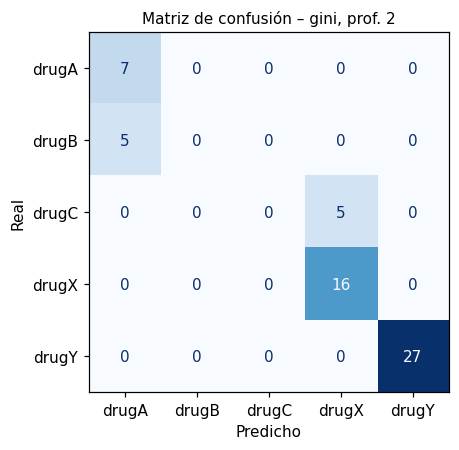

  CRITERIO: GINI  |  max_depth = 3
Exactitud en prueba: 0.9167

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.76      1.00      0.86        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.92        60
   macro avg       0.75      0.80      0.77        60
weighted avg       0.85      0.92      0.88        60



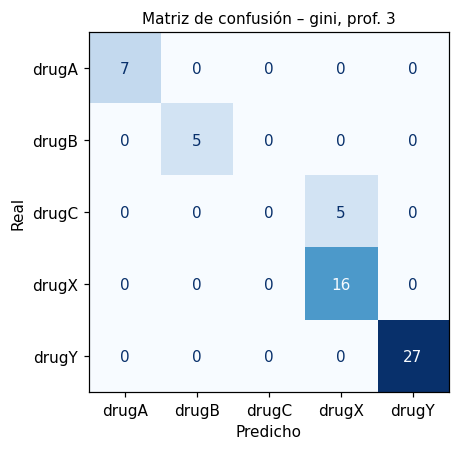

  CRITERIO: GINI  |  max_depth = 4
Exactitud en prueba: 1.0000

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



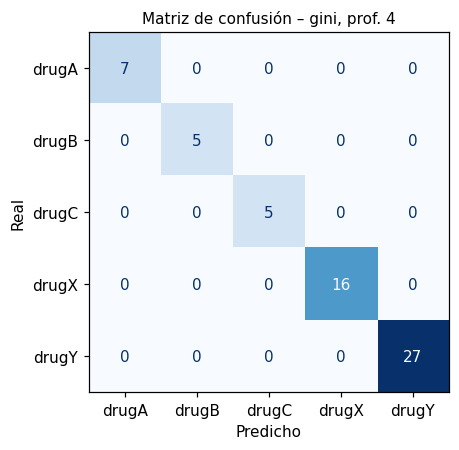

  CRITERIO: GINI  |  max_depth = Sin límite
Exactitud en prueba: 1.0000

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



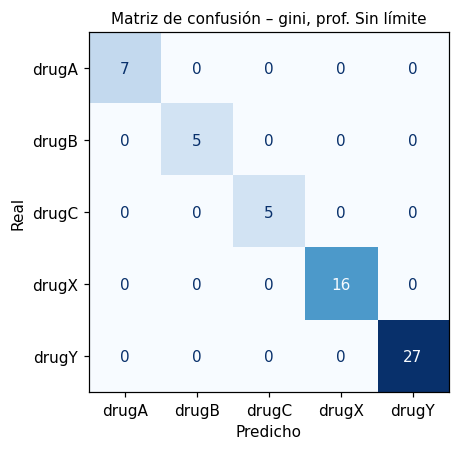

In [12]:
for p in [2, 3, 4, None]:
    reporte('gini', p)

### 6.2 Criterio Entropía

  CRITERIO: ENTROPY  |  max_depth = 2
Exactitud en prueba: 0.8333

              precision    recall  f1-score   support

       drugA       0.58      1.00      0.74         7
       drugB       0.00      0.00      0.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.76      1.00      0.86        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.83        60
   macro avg       0.47      0.60      0.52        60
weighted avg       0.72      0.83      0.77        60



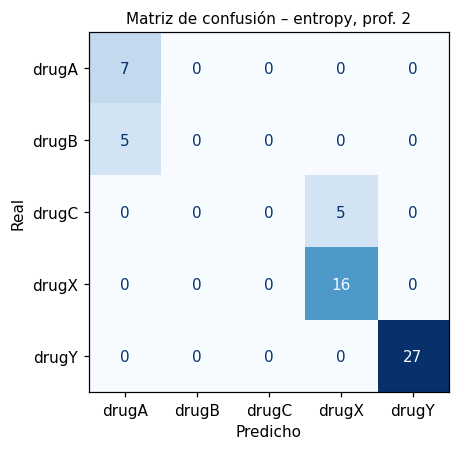

  CRITERIO: ENTROPY  |  max_depth = 3
Exactitud en prueba: 0.9167



              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.76      1.00      0.86        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.92        60
   macro avg       0.75      0.80      0.77        60
weighted avg       0.85      0.92      0.88        60



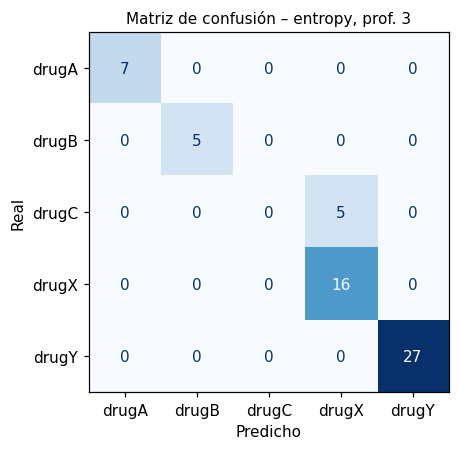

  CRITERIO: ENTROPY  |  max_depth = 4
Exactitud en prueba: 1.0000

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



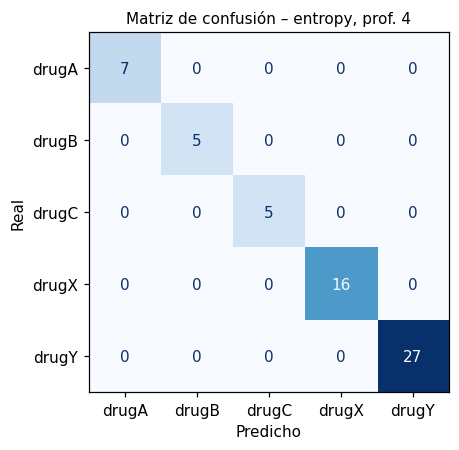

  CRITERIO: ENTROPY  |  max_depth = Sin límite
Exactitud en prueba: 1.0000

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



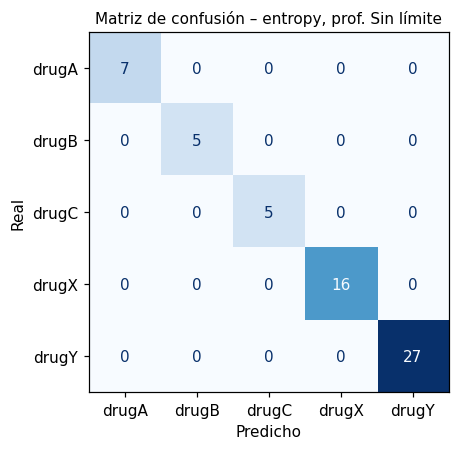

In [13]:
for p in [2, 3, 4, None]:
    reporte('entropy', p)

---
## 7. Interpretación de los indicadores y elección del mejor modelo

**Profundidad 2 (exactitud 0.833).** El reporte muestra `precision = recall = 0.00` en **drugB y
drugC**: el modelo nunca las predice, porque con 3 hojas solo tiene tres respuestas posibles para
cinco fármacos. Esos pacientes se van a parar a las hojas de drugA y drugX, cuya precision cae a
0.58 y 0.76 (aciertan a todos los suyos, pero arrastran intrusos). El macro avg del f1 se desploma a
**0.52** aunque la exactitud global sea 0.83 — exactamente el espejismo que anticipamos por el
desbalance. Clínicamente sería inaceptable: quien necesita drugB nunca la recibiría.

**Profundidad 3 (exactitud 0.917).** El tercer nivel rescata a drugB (f1 = 1.00) y el macro avg del
f1 sube a 0.77, pero **drugC sigue en 0.00**: sus 5 pacientes se siguen etiquetando como drugX. La
matriz de confusión lo muestra con esa celda fuera de la diagonal.

**Profundidad 4 (exactitud 1.000).** Precision, recall y f1 valen **1.00 en las cinco clases**,
incluidas las minoritarias. La matriz de confusión es perfectamente diagonal: ningún paciente mal
clasificado. Macro avg y weighted avg coinciden en 1.00, lo que confirma que el acierto no viene de
favorecer a la clase mayoritaria.

**Profundidades 5, 6 y sin límite.** Producen exactamente el mismo árbol (profundidad real 4,
6 hojas). Fijar un límite mayor no aporta nada, solo abre la puerta a que con otros datos el árbol
crezca de más.

**Gini vs. entropía.** Resultados idénticos en toda la rejilla. La diferencia entre ambos criterios
es de matiz y este conjunto de datos tiene fronteras muy limpias, así que los dos encuentran los
mismos cortes. Como desempate práctico: **Gini es marginalmente más rápido** (no calcula
logaritmos), y **entropía es más didáctica** porque sus valores se leen en bits de información.

### ✅ Mejor opción

> **`DecisionTreeClassifier(criterion='entropy', max_depth=4)`**
> (equivalente en resultados a `criterion='gini', max_depth=4`)

**Por qué esta y no otra:** es la configuración **más simple** que alcanza el desempeño máximo. Por
el principio de parsimonia, entre dos modelos con idéntico desempeño se prefiere el más pequeño:
generaliza mejor, se explica más fácil y es más barato de mantener. Fijar `max_depth=4`
explícitamente —en lugar de dejarlo sin límite— también actúa como red de seguridad si mañana se
reentrena con datos nuevos y más ruidosos.

**Una advertencia profesional:** un 100 % de exactitud debe encender una alarma, no solo celebrarse.
Aquí se explica porque `drugs.csv` es un conjunto **sintético**, generado con reglas deterministas
(umbrales fijos de Na_to_K, presión, edad y colesterol) y sin ruido. Con pacientes reales jamás
esperaríamos algo así, y convendría validar con **validación cruzada** sobre varias particiones
antes de confiar en el número.

In [14]:
# Comprobación adicional: validación cruzada de 5 pliegues
from sklearn.model_selection import cross_val_score

mejor = DecisionTreeClassifier(criterion='entropy', max_depth=4,
                               random_state=RANDOM_STATE)
puntajes = cross_val_score(mejor, X, y, cv=5, scoring='accuracy')
print('Exactitud por pliegue:', np.round(puntajes, 4))
print(f'Media: {puntajes.mean():.4f}  |  '
      f'Desviación estándar: {puntajes.std():.4f}')

Exactitud por pliegue: [1.    1.    1.    0.925 1.   ]
Media: 0.9850  |  Desviación estándar: 0.0300


La validación cruzada entrena y evalúa cinco veces, rotando qué 20 % de la base se usa como
prueba, de modo que **cada paciente es evaluado exactamente una vez** por un modelo que no lo vio.
El resultado —media **0.985** con desviación estándar 0.030— confirma que el desempeño no dependió
de una partición afortunada. El único pliegue por debajo de 1.00 (0.925) es esperable: al rotar las
particiones, algún pliegue queda con muy pocos casos de las clases minoritarias.

---
## 8. El árbol elegido: visualización y reglas

Entrenamos el modelo definitivo y lo dibujamos. En cada nodo se lee: la pregunta, la impureza
(entropía), cuántas muestras llegan, cómo se reparten entre clases y la clase mayoritaria.

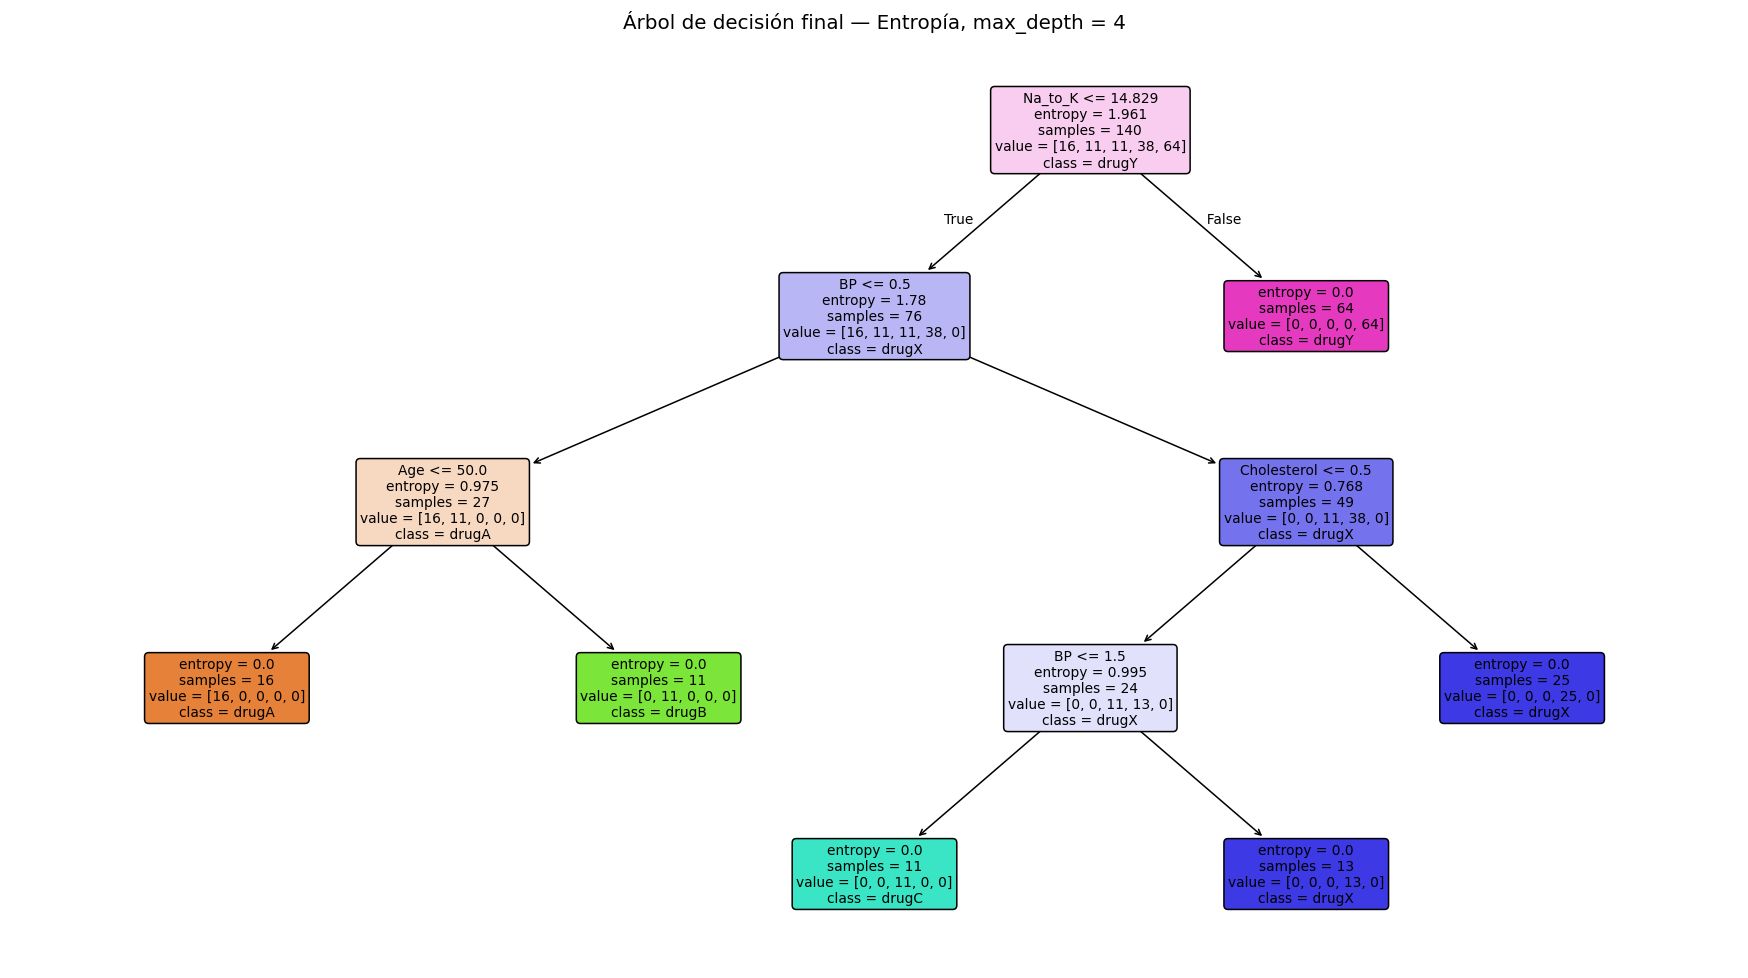

In [15]:
arbol = DecisionTreeClassifier(criterion='entropy', max_depth=4,
                               random_state=RANDOM_STATE)
arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(16, 9))
plot_tree(arbol,
          feature_names=list(X.columns),
          class_names=sorted(y.unique()),
          filled=True, rounded=True, fontsize=9, impurity=True, ax=ax)
ax.set_title('Árbol de decisión final — Entropía, max_depth = 4',
             fontsize=13)
plt.tight_layout(); plt.show()

In [16]:
# Las mismas reglas en formato de texto
print(export_text(arbol, feature_names=list(X.columns)))

|--- Na_to_K <= 14.83
|   |--- BP <= 0.50
|   |   |--- Age <= 50.00
|   |   |   |--- class: drugA
|   |   |--- Age >  50.00
|   |   |   |--- class: drugB
|   |--- BP >  0.50
|   |   |--- Cholesterol <= 0.50
|   |   |   |--- BP <= 1.50
|   |   |   |   |--- class: drugC
|   |   |   |--- BP >  1.50
|   |   |   |   |--- class: drugX
|   |   |--- Cholesterol >  0.50
|   |   |   |--- class: drugX
|--- Na_to_K >  14.83
|   |--- class: drugY



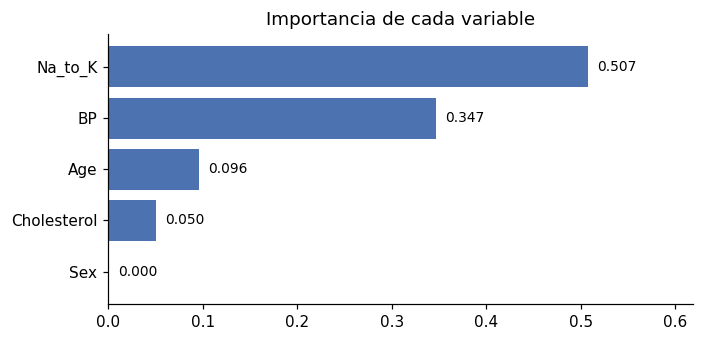

Na_to_K        0.5072
BP             0.3468
Age            0.0959
Cholesterol    0.0501
Sex            0.0000


In [17]:
# ¿Qué tanto pesa cada variable en las decisiones del árbol?
importancias = (pd.Series(arbol.feature_importances_, index=X.columns)
                  .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.barh(importancias.index, importancias.values, color='#4C72B0')
for i, v in enumerate(importancias.values):
    ax.text(v + .01, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlim(0, importancias.max() * 1.22)
ax.set_title('Importancia de cada variable')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

print(importancias.sort_values(ascending=False).round(4).to_string())

---
## 9. Explicación verbal de las reglas del árbol

Traduciendo los cortes numéricos a lenguaje clínico (recordando BP: HIGH=0, LOW=1, NORMAL=2 y
Cholesterol: HIGH=0, NORMAL=1):

### Regla 1 — la pregunta que más discrimina
> **Si `Na_to_K` > 14.83 → el paciente responde a `drugY`.**

Es la primera pregunta del árbol y por sí sola resuelve casi la mitad de los casos, sin necesidad de
mirar edad, sexo, presión ni colesterol. Por eso `Na_to_K` domina el gráfico de importancias: una
razón sodio/potasio elevada es el indicador decisivo de que corresponde drugY.

### Si `Na_to_K` ≤ 14.83, la siguiente pregunta es la presión arterial

**Rama A — presión ALTA (`BP = HIGH`):** ahora decide la **edad**.
> - **Edad ≤ 50 años → `drugA`**
> - **Edad > 50 años → `drugB`**
>
> drugA y drugB atienden al mismo perfil (Na_to_K bajo + presión alta); lo único que los separa es
> la edad, con el corte en 50 años.

**Rama B — presión BAJA o NORMAL:** ahora decide el **colesterol**.
> - **Colesterol NORMAL → `drugX`** (sin importar si la presión es baja o normal)
> - **Colesterol ALTO** → se vuelve a mirar la presión:
>     - **presión BAJA → `drugC`**
>     - **presión NORMAL → `drugX`**

### Las 6 reglas completas, en una tabla

| # | Regla | Fármaco |
|---|---|---|
| 1 | Na_to_K > 14.83 | **drugY** |
| 2 | Na_to_K ≤ 14.83 · BP = HIGH · Edad ≤ 50 | **drugA** |
| 3 | Na_to_K ≤ 14.83 · BP = HIGH · Edad > 50 | **drugB** |
| 4 | Na_to_K ≤ 14.83 · BP = LOW · Colesterol = HIGH | **drugC** |
| 5 | Na_to_K ≤ 14.83 · BP = LOW/NORMAL · Colesterol = NORMAL | **drugX** |
| 6 | Na_to_K ≤ 14.83 · BP = NORMAL · Colesterol = HIGH | **drugX** |

### Observaciones sobre lo que el árbol *no* usó

El **sexo del paciente tiene importancia 0.000**: el árbol nunca lo necesitó para separar las
clases. Es un hallazgo con valor propio — sugiere que, en estos datos, la elección de fármaco no
depende del sexo. La **edad** solo interviene en una rama muy concreta (distinguir drugA de drugB),
y el **colesterol** únicamente cuando la presión no es alta. Un árbol no solo predice: también
muestra qué variables importan y cuáles se pueden dejar de medir.

---
## 10. Predicción para un paciente nuevo

Construimos una función reutilizable. El punto delicado es aplicar al paciente **exactamente la
misma codificación** que se usó al entrenar; si se invirtiera un código, el modelo respondería con
seguridad… y se equivocaría. Por eso la función usa los diccionarios `mapas` guardados en el paso 3
en vez de números escritos a mano.

In [18]:
def recomendar_farmaco(edad, sexo, presion, colesterol, na_to_k,
                       modelo=arbol, detalle=True):
    """Recomienda un fármaco para un paciente nuevo.

    edad       : int    -> años
    sexo       : str    -> 'F' o 'M'
    presion    : str    -> 'HIGH', 'LOW' o 'NORMAL'
    colesterol : str    -> 'HIGH' o 'NORMAL'
    na_to_k    : float  -> razón sodio/potasio
    """
    paciente = pd.DataFrame([{
        'Age': edad,
        'Sex': mapas['Sex'][sexo],
        'BP': mapas['BP'][presion],
        'Cholesterol': mapas['Cholesterol'][colesterol],
        'Na_to_K': na_to_k
    }])

    pred = modelo.predict(paciente)[0]
    probas = pd.Series(modelo.predict_proba(paciente)[0],
                       index=modelo.classes_)

    if detalle:
        print('Datos del paciente')
        print(f'  Edad            : {edad} años')
        print(f'  Sexo            : {sexo}')
        print(f'  Presión arterial: {presion}')
        print(f'  Colesterol      : {colesterol}')
        print(f'  Na_to_K         : {na_to_k}')
        print('\nCodificación aplicada:', paciente.iloc[0].to_dict())
        print(f'\n>>> FÁRMACO RECOMENDADO: {pred}')
        print('\nConfianza del modelo por clase:')
        print((probas * 100).round(1).astype(str).add(' %').to_string())
    return pred


# --- CASO DEL PACIENTE DE LA ACTIVIDAD ---------------------
# Sustituya estos valores por los del paciente del enunciado.
recomendar_farmaco(edad=40, sexo='M', presion='HIGH',
                   colesterol='HIGH', na_to_k=12.5)

Datos del paciente
  Edad            : 40 años
  Sexo            : M
  Presión arterial: HIGH
  Colesterol      : HIGH
  Na_to_K         : 12.5

Codificación aplicada: {'Age': 40.0, 'Sex': 1.0, 'BP': 0.0, 'Cholesterol': 0.0, 'Na_to_K': 12.5}

>>> FÁRMACO RECOMENDADO: drugA

Confianza del modelo por clase:
drugA    100.0 %
drugB      0.0 %
drugC      0.0 %
drugX      0.0 %
drugY      0.0 %


'drugA'

**Cómo se llegó a esa recomendación** (siga el árbol a mano para comprobarlo): con
`Na_to_K = 12.5` la primera pregunta (¿es > 14.83?) responde **no**, así que descartamos drugY.
La presión es **HIGH**, lo que nos manda a la rama de drugA/drugB. La edad es **40 ≤ 50**, luego la
respuesta es **drugA**. La probabilidad de 100 % refleja que la hoja donde cayó el paciente contiene
únicamente pacientes de drugA en el conjunto de entrenamiento — coherente con un árbol de nodos
puros, no con una certeza real sobre un paciente de carne y hueso.

In [19]:
# Verificación: un perfil real por cada fármaco, tomado de la base
casos = [
    dict(edad=23, sexo='F', presion='HIGH',   colesterol='HIGH',
         na_to_k=25.355),
    dict(edad=43, sexo='M', presion='HIGH',   colesterol='HIGH',
         na_to_k=13.972),
    dict(edad=74, sexo='M', presion='HIGH',   colesterol='HIGH',
         na_to_k=9.567),
    dict(edad=47, sexo='M', presion='LOW',    colesterol='HIGH',
         na_to_k=13.093),
    dict(edad=28, sexo='F', presion='NORMAL', colesterol='HIGH',
         na_to_k=7.798),
]
esperados = ['drugY', 'drugA', 'drugB', 'drugC', 'drugX']

filas = []
for caso, esp in zip(casos, esperados):
    obtenido = recomendar_farmaco(**caso, detalle=False)
    filas.append({**caso, 'Esperado': esp, 'Predicho': obtenido,
                  '¿Coincide?': '✓' if obtenido == esp else '✗'})

pd.DataFrame(filas)

,edad,sexo,presion,colesterol,na_to_k,Esperado,Predicho,¿Coincide?
0,23,F,HIGH,HIGH,25.355,drugY,drugY,✓
1,43,M,HIGH,HIGH,13.972,drugA,drugA,✓
2,74,M,HIGH,HIGH,9.567,drugB,drugB,✓
3,47,M,LOW,HIGH,13.093,drugC,drugC,✓
4,28,F,NORMAL,HIGH,7.798,drugX,drugX,✓


Los cinco perfiles (tomados de pacientes reales de la base) se predicen correctamente, uno por
cada fármaco. La función y las reglas verbales son consistentes entre sí.

---
## 11. Conclusiones

1. **Los datos estaban limpios pero desbalanceados** (200 registros, sin nulos; drugY 45.5 % frente
   a drugB y drugC con 8 % cada uno). Ese desbalance obligó a evaluar por clase y no solo con la
   exactitud global.

2. **`LabelEncoder` resolvió la conversión de las variables cualitativas** a escala numérica
   (Sex: F=0/M=1; BP: HIGH=0/LOW=1/NORMAL=2; Cholesterol: HIGH=0/NORMAL=1). Guardar los mapeos fue
   indispensable para después traducir las reglas y codificar pacientes nuevos sin errores.

3. **Gini y entropía dieron resultados idénticos** en todas las profundidades probadas. La
   profundidad fue el parámetro que sí importó: 2 niveles subajustan (83 %, con tres clases nunca
   predichas), 3 se quedan cerca (92 %) y **4 alcanzan el 100 % en las cinco clases**. Más
   profundidad no cambia el árbol.

4. **Modelo elegido: entropía con `max_depth=4`** — el más simple que logra el desempeño máximo,
   con precision, recall y f1 de 1.00 por clase, matriz de confusión diagonal y validación cruzada
   estable.

5. **La razón sodio/potasio (`Na_to_K`) es la variable dominante**; le siguen presión arterial,
   edad y colesterol. **El sexo resultó irrelevante** (importancia 0).

6. **El árbol es interpretable**: seis reglas en lenguaje natural bastan para reproducir a mano
   cualquier recomendación, algo especialmente valioso en un contexto médico donde la decisión debe
   poder justificarse ante un paciente.

7. **Reserva metodológica.** Un 100 % de exactitud indica que `drugs.csv` es un conjunto sintético
   con reglas deterministas. Con datos clínicos reales habría ruido, casos ambiguos y comorbilidades;
   el modelo debería revalidarse y, muy probablemente, requeriría podado, más variables y una
   evaluación centrada en el recall de las clases minoritarias.
